# Revenue & Customer Analytics — Olist (Brazilian E-Commerce)

**Role simulated:** Data Analyst · **Question:** *Which customers and categories drive profit, and who is about to leave?*

End-to-end flow: raw CSV → DuckDB star schema (`sql/01_schema.sql`) → 11 analytics marts (`sql/02_marts.sql`) → analysis → charts → executive findings.

**Dataset:** Kaggle *Brazilian E-Commerce by Olist* — 99,441 orders, 112,650 order items, 96,096 unique customers, Sep 2016 – Sep 2018.

Run `scripts/01_build_warehouse.py` and `scripts/02_analysis.py` first (they write the CSVs this notebook reads).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 9,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold'})
NAVY, TEAL, AMBER, RED, GREY = '#1f3b63', '#2a9d8f', '#e9a13b', '#d64545', '#8d99ae'

P = Path('../data/processed')   # adjust if you run from another cwd
def load(n): return pd.read_csv(P / f'{n}.csv')

kpi   = load('mart_monthly_kpi');   kpi['order_month'] = pd.to_datetime(kpi['order_month'])
rfm   = load('mart_rfm')
segs  = load('mart_rfm_segments')
coh   = load('mart_cohort');        coh['cohort_month'] = pd.to_datetime(coh['cohort_month'])
par   = load('mart_pareto')
cat   = load('mart_category')
state = load('mart_state')
sla   = load('mart_delivery_sla');  sla['order_month'] = pd.to_datetime(sla['order_month'])
pay   = load('mart_payment')
rep   = load('mart_repeat')
rd    = load('mart_review_delay')
orders = load('fact_order_summary')
print('loaded', len(kpi), 'months ·', len(rfm), 'customers ·', len(orders), 'order rows')

loaded 24 months · 94399 customers · 99994 order rows


## 1. Data quality — what we verified before trusting anything

| check | result |
|---|---|
| orders with a resolvable unique-customer key | 99,441 / 99,441 |
| duplicate order ids | 0 |
| order items or payments with orphan order_id | 0 |
| negative/missing prices or freight | 0 |
| delivered orders missing delivery timestamp | 8 (0.008%) |
| revenue reconciliation: item-based vs payment-based | +16.0% gap (documented below) |

The 16% gap between *item price + freight* (R$13.44M) and *payments* (R$15.60M) is a known Olist property: `payment_value` also contains orders later cancelled after payment, and some orders carry multiple payment rows. We report revenue on the **item basis** and disclose the gap — hiding it would be the red flag.

In [2]:
dq = json.load(open('../reports/data_quality.json'))
for k, v in dq.items():
    print(f'{k:<38} {v}')

orders_total                           99441
orders_null_customer_key               0
orders_duplicate_order_id              0
items_orphan_order_id                  0
payments_orphan_order_id               0
items_missing_product_id               0
items_negative_price                   0
items_null_freight                     0
products_null_category                 610
customers_unique_ids                   96350
customers_with_multiple_order_ids      2770
orders_missing_delivered_ts            8
delivered_after_estimate               6535
revenue_item_based                     13443534.14
revenue_payments_based                 15599675.73
revenue_reconciliation_gap_pct         16.04


## 2. Revenue trend

The 2016 rows are a marketplace ramp-up (Sep-16: 2 orders, Dec-16: 1 order), so growth is measured on the **Jan-17 → Aug-18** window (grey bars excluded).

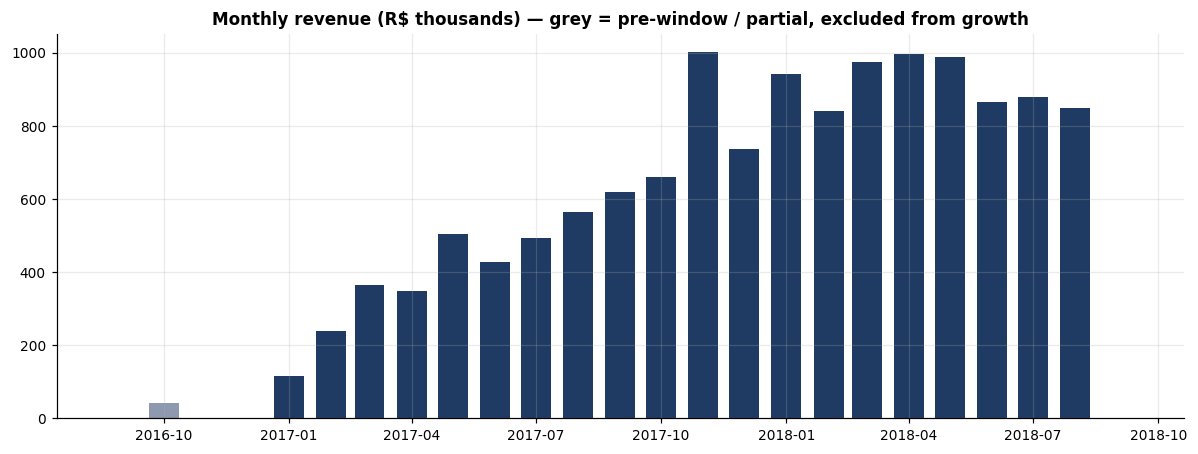

window revenue  R$13.40M
growth first->last month  638%
peak month  Nov-2017 (R$1.00M)


In [3]:
kpi['partial'] = kpi['order_month'].isin([kpi['order_month'].min(), kpi['order_month'].max()])
kpi['in_window'] = (kpi['order_month'] >= pd.Timestamp('2017-01-01')) & ~kpi['partial']

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.bar(kpi['order_month'], kpi['revenue']/1e3,
       color=[NAVY if w else GREY for w in kpi['in_window']], width=22)
ax.set_title('Monthly revenue (R$ thousands) — grey = pre-window / partial, excluded from growth')
plt.tight_layout(); plt.show()

w = kpi[kpi['in_window']].reset_index(drop=True)
print(f"window revenue  R${w['revenue'].sum()/1e6:.2f}M")
print(f"growth first->last month  {100*(w['revenue'].iloc[-1]/w['revenue'].iloc[0]-1):.0f}%")
print(f"peak month  {w.loc[w['revenue'].idxmax(),'order_month']:%b-%Y} (R${w['revenue'].max()/1e6:.2f}M)")

## 3. RFM segmentation

**Method note (interview question!):** `frequency` has only 9 distinct values and 96.97% of customers sit at exactly 1 order, so a quintile split (`NTILE`) would carve identical customers into different tiers. We score **F on its distinct values** (1 / 2 / 3-4 / 5+ orders), while R and M use proper quintiles against the last order date in the data (a snapshot, not `today()`).

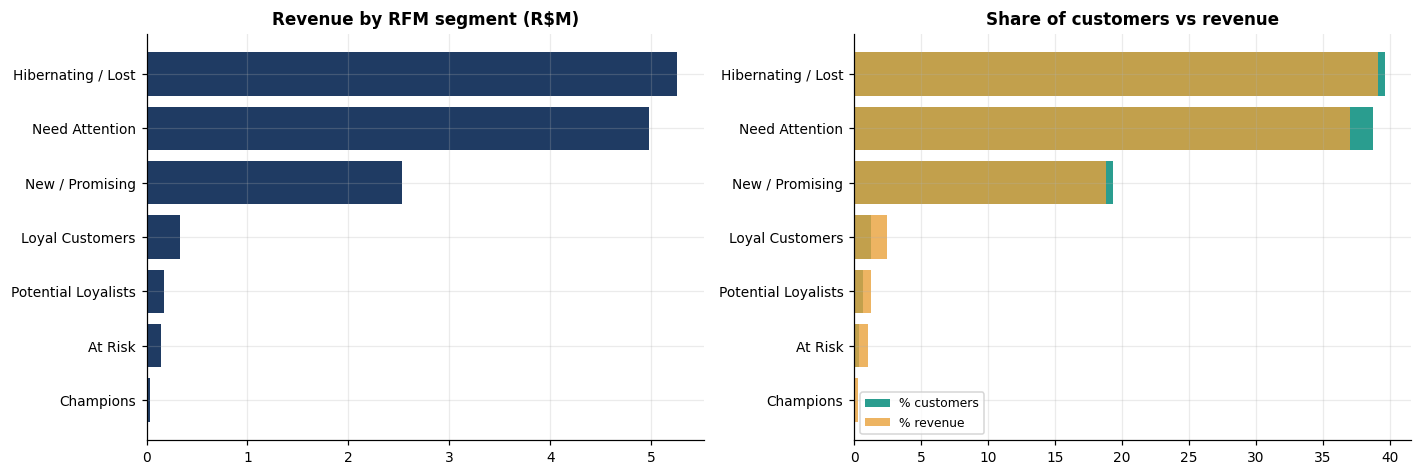

,segment,customers,pct_customers,revenue,pct_revenue,avg_monetary,avg_frequency,avg_recency_days
0,Hibernating / Lost,37404,39.62,5258322.69,39.11,140.59,1.02,400.0
1,Need Attention,36556,38.72,4977651.97,37.03,136.17,1.00,182.0
2,New / Promising,18240,19.32,2530729.63,18.82,138.75,1.00,50.0
3,Loyal Customers,1166,1.24,332665.85,2.47,285.31,2.07,96.0
4,Potential Loyalists,615,0.65,170793.36,1.27,277.71,2.09,222.0
5,At Risk,356,0.38,138591.51,1.03,389.30,2.11,322.0
6,Champions,62,0.07,34779.13,0.26,560.95,3.69,49.0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
s = segs.sort_values('revenue')
axes[0].barh(s['segment'], s['revenue']/1e6, color=NAVY)
axes[0].set_title('Revenue by RFM segment (R$M)')
s2 = segs.sort_values('pct_revenue', ascending=False)
axes[1].barh(s2['segment'], s2['pct_customers'], color=TEAL, label='% customers')
axes[1].barh(s2['segment'], s2['pct_revenue'], color=AMBER, alpha=.8, label='% revenue')
axes[1].invert_yaxis(); axes[1].legend(fontsize=8)
axes[1].set_title('Share of customers vs revenue')
plt.tight_layout(); plt.show()

segs[['segment','customers','pct_customers','revenue','pct_revenue','avg_monetary','avg_frequency','avg_recency_days']]

## 4. Cohort retention — the uncomfortable truth

M+1 retention sits near **0.5%** for almost every cohort. This is a pure-acquisition marketplace: 97% of customers never return. That is the single most important finding of the analysis — every recommendation below follows from it.

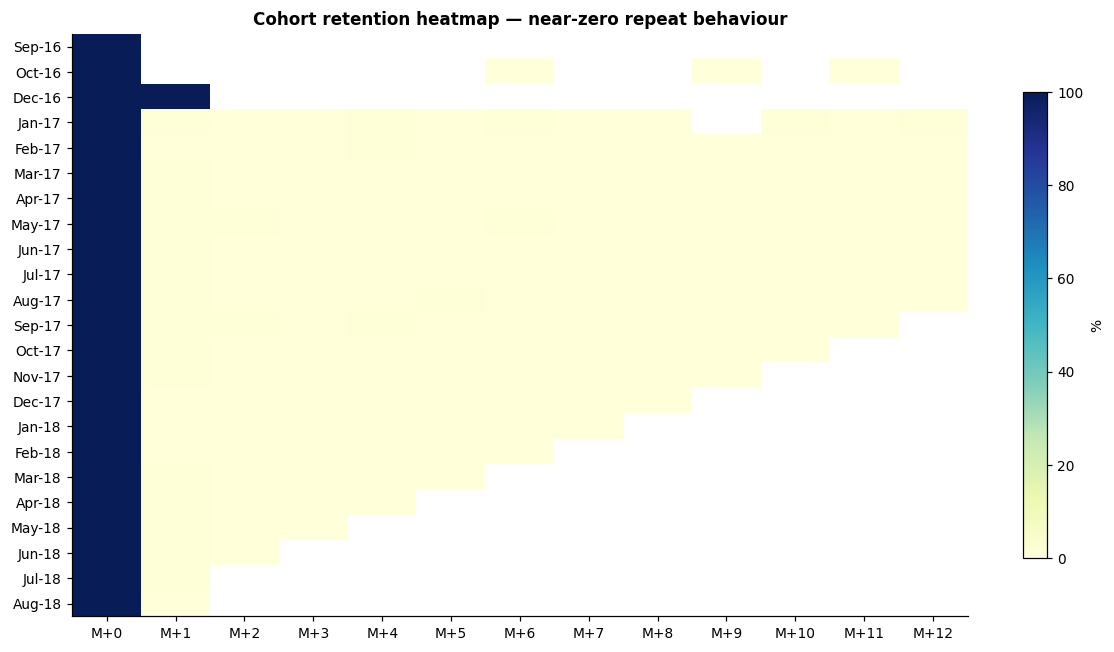

median M+1 retention: 0.51%


In [5]:
wide = coh.pivot_table(index='cohort_month', columns='month_offset', values='retention_pct', aggfunc='first')
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(wide[wide.columns[wide.columns <= 12]].values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=100)
ax.set_xticks(range(13), [f'M+{c}' for c in range(13)])
ax.set_yticks(range(len(wide)), [f"{d:%b-%y}" for d in wide.index])
ax.grid(False); fig.colorbar(im, ax=ax, shrink=.8, label='%')
ax.set_title('Cohort retention heatmap — near-zero repeat behaviour')
plt.tight_layout(); plt.show()

m1 = coh[coh['month_offset']==1]; m1 = m1[m1['cohort_size']>1000]
print(f"median M+1 retention: {m1['retention_pct'].median():.2f}%")

## 5. Pareto — where the money actually is

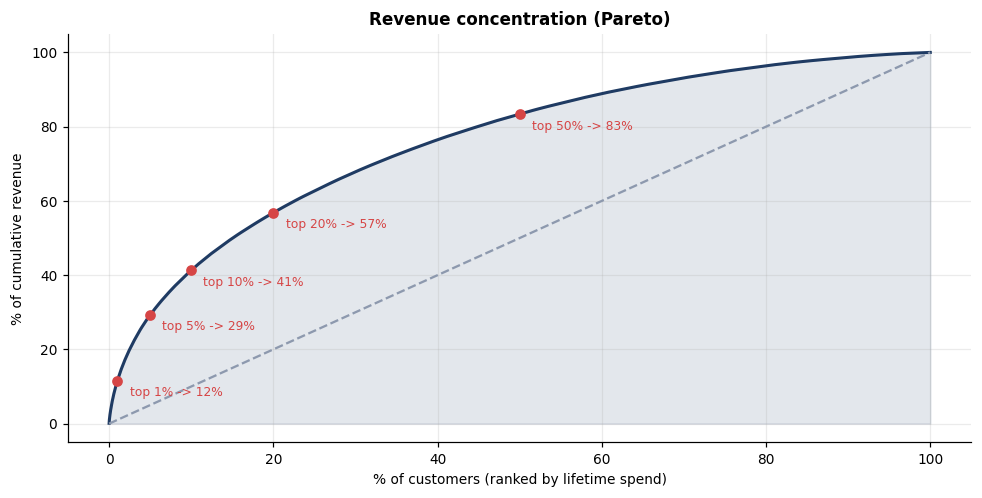

one-time buyers: 96.97% of customers


In [6]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.plot(par['pct_customers'], par['pct_revenue'], color=NAVY, lw=2)
ax.fill_between(par['pct_customers'], par['pct_revenue'], alpha=.12, color=NAVY)
ax.plot([0,100],[0,100], ls='--', color=GREY)
for pct in (1,5,10,20,50):
    row = par.iloc[min(int(len(par)*pct/100)-1, len(par)-1)]
    ax.scatter([pct],[row['pct_revenue']], color=RED, zorder=5)
    ax.annotate(f"top {pct}% -> {row['pct_revenue']:.0f}%", (pct, row['pct_revenue']),
                textcoords='offset points', xytext=(8,-10), fontsize=8, color=RED)
ax.set_xlabel('% of customers (ranked by lifetime spend)')
ax.set_ylabel('% of cumulative revenue')
ax.set_title('Revenue concentration (Pareto)')
plt.tight_layout(); plt.show()

print('one-time buyers:', f"{rep.loc[rep['order_bucket']=='1 order','pct_customers'].iloc[0]}% of customers")

## 6. Category & geography

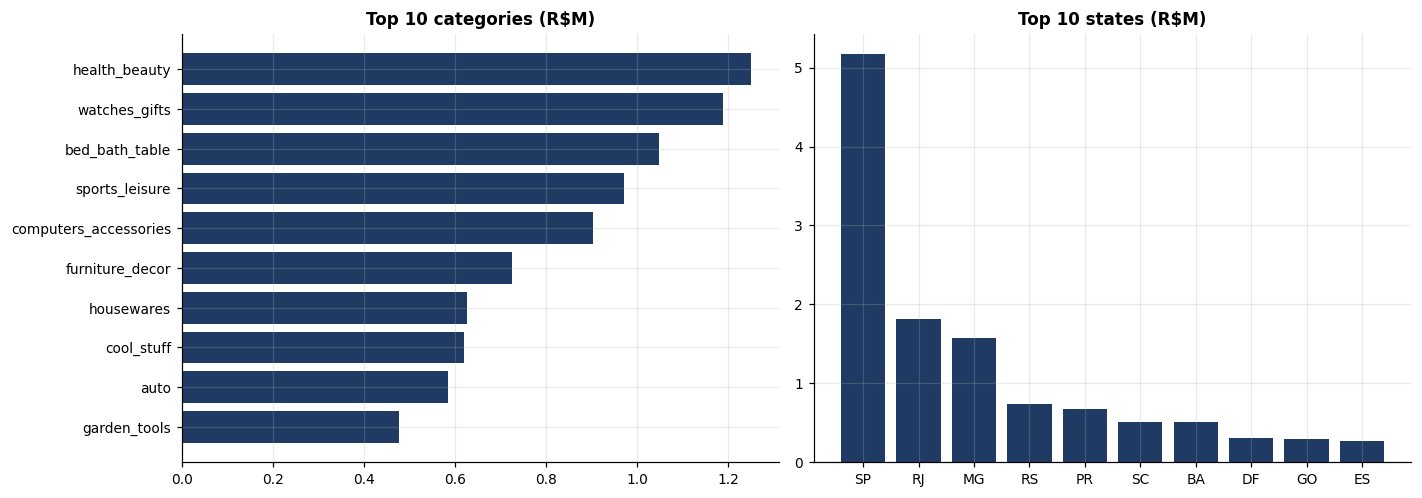

             category    revenue  pct_revenue  avg_review_score
        health_beauty 1250598.52         9.31              4.17
        watches_gifts 1190114.72         8.86              4.05
       bed_bath_table 1048116.04         7.80              3.90
       sports_leisure  972036.41         7.24              4.14
computers_accessories  904258.73         6.73              3.96


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
t = cat.head(10).iloc[::-1]
axes[0].barh(t['category'], t['revenue']/1e6, color=NAVY)
axes[0].set_title('Top 10 categories (R$M)')
t2 = state.head(10)
axes[1].bar(t2['customer_state'], t2['revenue']/1e6, color=NAVY)
axes[1].set_title('Top 10 states (R$M)')
plt.tight_layout(); plt.show()
print(cat.head(5)[['category','revenue','pct_revenue','avg_review_score']].to_string(index=False))

## 7. Delivery SLA vs satisfaction — the one causal-looking lever

We compare review scores for orders delivered on time vs late with a Welch t-test.

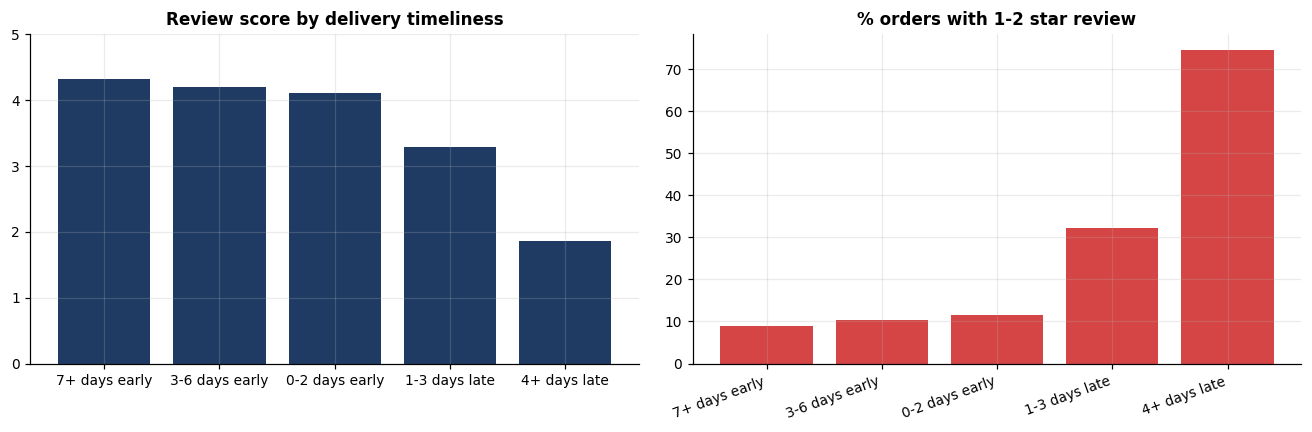

late orders: 6,417 (6.7%)  score 2.27 vs 4.29 on-time · Welch t=-101.0, p=0.00e+00


In [8]:
rd2 = rd[rd['delivery_bucket'] != 'no data']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(rd2['delivery_bucket'], rd2['avg_review_score'], color=NAVY)
axes[0].set_title('Review score by delivery timeliness'); axes[0].set_ylim(0, 5)
axes[1].bar(rd2['delivery_bucket'], rd2['pct_bad_reviews'], color=RED)
axes[1].set_title('% orders with 1-2 star review')
for lbl in axes[1].get_xticklabels(): lbl.set_rotation(20); lbl.set_ha('right')
plt.tight_layout(); plt.show()

late   = orders.dropna(subset=['days_vs_estimate','avg_review_score'])
df = late
g_late = df[df['days_vs_estimate'] < 0]['avg_review_score']
g_on   = df[df['days_vs_estimate'] >= 0]['avg_review_score']
t, p = stats.ttest_ind(g_late, g_on, equal_var=False)
print(f'late orders: {len(g_late):,} ({100*len(g_late)/len(df):.1f}%)  '
      f'score {g_late.mean():.2f} vs {g_on.mean():.2f} on-time · Welch t={t:.1f}, p={p:.2e}')

## 8. Findings → recommendations (the part that gets you hired)

1. **Retention is the growth gap.** 97% one-time buyers, M+1 retention ~0.5%. Start a post-purchase win-back flow (email/WhatsApp coupon at day 30) targeted at the *New / Promising* + *Need Attention* segments (~58% of customers).
2. **Protect the whales.** Top 10% of customers = 41% of revenue; *At Risk* (356 high-value, 2+ orders, ~10-11 months silent) hold R$138K of proven spend → give them concierge support + a personalised offer this month.
3. **Delivery is CSAT.** 4+ days late → 74.6% bad reviews vs 8.9% early (p≈0). Renegotiate carrier SLAs in the slowest northern states (RR 28.2d avg vs SP ~11d) and set a 90% on-time target.
4. **Concentrate the catalogue.** health_beauty + computers_accessories + furniture ≈ 26% of revenue; fix stock-outs there first.
5. **Payments are cards.** 78.5% of value on credit card, 3.5 avg instalments → negotiate instalment-fee economics, not just MDR.

> Every number above is reproducible from `data/processed/*.csv`.